# Order Prediction Pipeline

In [1]:
# Imports and Configurations
# ================================================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing   import OneHotEncoder, RobustScaler
from sklearn.impute          import SimpleImputer
from sklearn.tree            import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.ensemble        import RandomForestClassifier
from sklearn.metrics         import (classification_report, roc_auc_score,
                                     confusion_matrix, f1_score, precision_recall_curve,
                                     average_precision_score, ConfusionMatrixDisplay)

from scipy.sparse            import hstack
import xgboost as xgb

import seaborn as sns
from pathlib import Path

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import gc

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# Load & Merge Data (train.csv + items.csv)
# ================================================================================================

train = pd.read_csv('../data/raw/train.csv', sep='|')
items = pd.read_csv('../data/raw/items.csv', sep='|')

df = train.merge(items, on='pid', how='left', validate='m:1')

print("Data loaded and merged.")

Data loaded and merged.


## DATA PREPARATION

In [3]:
# Stratified Sampling (if SAMPLING < 1)
# ================================================================================================

SAMPLING = 1

df = df.sort_values(['day', 'lineID']).reset_index(drop=True)

if SAMPLING < 1.0:
    df = (df.groupby('day', group_keys=False)
            .sample(frac=SAMPLING, random_state=42)
            .sort_values(['day', 'lineID'])
            .reset_index(drop=True))

print(f"Using {len(df):,} rows ({SAMPLING*100:.0f}% sample).")

Using 2,756,003 rows (100% sample).


In [4]:
# Train / Test Split (chronological, day-based)
# ================================================================================================

X = df.drop(columns=['order']).copy()
y = df['order'].copy()

# Stable identifier for re-alignment after sorting
X['_orig_idx'] = X.index

unique_days = sorted(df['day'].unique())
cutoff = unique_days[int(len(unique_days) * 0.8)]

X_train = X[X['day'] < cutoff].copy()
X_test  = X[X['day'] >= cutoff].copy()

y_train = y.loc[X_train.index].copy()
y_test  = y.loc[X_test.index].copy()

In [5]:
# Summary Statistics
# ================================================================================================
print(f"Train size: {len(X_train):,}  |  Test size: {len(X_test):,}")
print(f"Train positive rate: {y_train.mean():.3f}  |  Test positive rate: {y_test.mean():.3f}")
print(f"Train days: {X_train['day'].min()}–{X_train['day'].max()} | Test days: {X_test['day'].min()}–{X_test['day'].max()}")

Train size: 2,125,239  |  Test size: 630,764
Train positive rate: 0.259  |  Test positive rate: 0.245
Train days: 1–73 | Test days: 74–92


In [6]:
# Helper Function: build_expanding_train_features (vectorized)
# ================================================================================================

"""Leak-prevention strategy: for each day, compute features based only on past days, then update state with today's data.
    Compute leak-free expanding-window features:
    - pid_order/click/basket rates
    - price std, target encodings
    - days_since_last_click, days_since_last_basket,
      click_streak_7d, last_event_was_click,
      click_to_order_conv, basket_to_order_conv
    """

def build_expanding_train_features(df, y_series):
    """
    Vectorized leak-free expanding-window feature builder.
    
    Mathematically equivalent to the original loop-based version.
    ~50-100x faster through pandas groupby/cumsum/shift operations.
    
    Features computed (all using PAST days only):
    - pid_order/click/basket_rate
    - pid_price_std, pid_seen_in_train
    - manufacturer_te, group_te, category_te (smoothed)
    - days_since_last_click, days_since_last_basket
    - click_streak_7d, last_event_was_click
    - click_to_order_conv, basket_to_order_conv (smoothed)
    """
    SMOOTHING = 10
    
    df = df.copy()
    df['__y__'] = y_series.reindex(df.index).to_numpy().astype(int)
    df = df.sort_values(['day', 'lineID']).reset_index(drop=True)

    # ============================================================
    # PART 1: Aggregate per (pid, day) — once
    # ============================================================
    daily = df.groupby(['pid', 'day'], sort=False).agg(
        n=('__y__', 'size'),
        n_orders=('__y__', 'sum'),
        n_clicks=('click', 'sum'),
        n_baskets=('basket', 'sum'),
        sum_price=('price', 'sum'),
        sum_price_sq=('price', lambda x: (x ** 2).sum()),
    ).reset_index()

    daily = daily.sort_values(['pid', 'day']).reset_index(drop=True)

    # ============================================================
    # PART 2: Per-pid expanding cumulatives (shifted to exclude today)
    # ============================================================
    g = daily.groupby('pid', sort=False)
    
    for col in ['n', 'n_orders', 'n_clicks', 'n_baskets', 'sum_price', 'sum_price_sq']:
        daily[f'cum_{col}'] = g[col].cumsum().shift(1)
    
    # Reset at pid boundaries (shift(1) leaks across pids)
    first_in_pid = daily['pid'] != daily['pid'].shift(1)
    cum_cols = ['cum_n', 'cum_n_orders', 'cum_n_clicks', 'cum_n_baskets',
                'cum_sum_price', 'cum_sum_price_sq']
    daily.loc[first_in_pid, cum_cols] = 0
    daily[cum_cols] = daily[cum_cols].fillna(0)

    # ============================================================
    # PART 3: Global order rate up to (excluding) each day
    # ============================================================
    global_daily = df.groupby('day', sort=True).agg(
        day_n=('__y__', 'size'),
        day_orders=('__y__', 'sum'),
    ).reset_index()
    global_daily['cum_n_global']      = global_daily['day_n'].cumsum().shift(1).fillna(0)
    global_daily['cum_orders_global'] = global_daily['day_orders'].cumsum().shift(1).fillna(0)
    global_daily['prev_rate'] = np.where(
        global_daily['cum_n_global'] > 0,
        global_daily['cum_orders_global'] / global_daily['cum_n_global'].replace(0, 1),
        0.0
    )

    daily = daily.merge(global_daily[['day', 'prev_rate']], on='day', how='left')

    # ============================================================
    # PART 4: Per-pid rates
    # ============================================================
    has_history = daily['cum_n'] > 0
    safe_n = daily['cum_n'].replace(0, 1)

    daily['pid_seen_in_train'] = has_history.astype(int)
    daily['pid_order_rate']  = np.where(has_history, daily['cum_n_orders']  / safe_n, daily['prev_rate'])
    daily['pid_click_rate']  = np.where(has_history, daily['cum_n_clicks']  / safe_n, daily['prev_rate'])
    daily['pid_basket_rate'] = np.where(has_history, daily['cum_n_baskets'] / safe_n, daily['prev_rate'])

    # Price std (population, ddof=0): sqrt(E[X^2] - E[X]^2)
    mean_p  = daily['cum_sum_price']    / safe_n
    mean_p2 = daily['cum_sum_price_sq'] / safe_n
    var_p = (mean_p2 - mean_p ** 2).clip(lower=0)
    daily['pid_price_std'] = np.sqrt(var_p)
    daily.loc[daily['cum_n'] < 2, 'pid_price_std'] = 0.0
    daily['pid_price_std'] = daily['pid_price_std'].fillna(0.0)

    # Conversion rates (smoothed)
    denom_click = daily['cum_n_clicks']  + daily['cum_n_orders'] + SMOOTHING
    denom_basket = daily['cum_n_baskets'] + daily['cum_n_orders'] + SMOOTHING
    daily['click_to_order_conv']  = (daily['cum_n_orders'] + daily['prev_rate'] * SMOOTHING) / denom_click
    daily['basket_to_order_conv'] = (daily['cum_n_orders'] + daily['prev_rate'] * SMOOTHING) / denom_basket

    # ============================================================
    # PART 5: Recency features
    # ============================================================
    # "Pure" event days (event happened but no order)
    daily['had_pure_click']  = ((daily['n_clicks']  > 0) & (daily['n_orders'] == 0)).astype(int)
    daily['had_pure_basket'] = ((daily['n_baskets'] > 0) & (daily['n_orders'] == 0)).astype(int)

    # Last pure-click day (excluding today via shift)
    daily['last_click_day'] = daily['day'].where(daily['had_pure_click'] == 1)
    daily['last_click_day'] = daily.groupby('pid', sort=False)['last_click_day'].shift(1)
    daily['last_click_day'] = daily.groupby('pid', sort=False)['last_click_day'].ffill()
    daily['days_since_last_click'] = (daily['day'] - daily['last_click_day']).fillna(999)

    daily['last_basket_day'] = daily['day'].where(daily['had_pure_basket'] == 1)
    daily['last_basket_day'] = daily.groupby('pid', sort=False)['last_basket_day'].shift(1)
    daily['last_basket_day'] = daily.groupby('pid', sort=False)['last_basket_day'].ffill()
    daily['days_since_last_basket'] = (daily['day'] - daily['last_basket_day']).fillna(999)

    # Click streak: pure clicks in past 6 calendar days (excluding today)
    # Need calendar-based, not observation-based: count clicks where day_event > today - 7

    # Approach: for each (pid, day), count rows in same pid where:
    #   - had_pure_click == 1
    #   - day_event in [day - 6, day - 1]
    # Implementation via merge-asof-like trick: build a long table of pure click days per pid,
    # then for each row count how many fall in the window.

    # Get all (pid, day) where pure click occurred
    pure_clicks = daily.loc[daily['had_pure_click'] == 1, ['pid', 'day']].copy()
    pure_clicks = pure_clicks.rename(columns={'day': 'click_day'})

    # Create a calendar-aware rolling sum for 7-day click streak
    temp_clicks = daily[['pid', 'day', 'had_pure_click']].copy()
    # Convert day to a timedelta for calendar-aware rolling
    temp_clicks['day_td'] = pd.to_timedelta(temp_clicks['day'], unit='D')
    temp_clicks = temp_clicks.set_index('day_td')

    # Click streak: pure clicks in past 6 calendar days (excluding today)
    pure_clicks = daily.loc[daily['had_pure_click'] == 1, ['pid', 'day']].copy()
    pure_clicks = pure_clicks.rename(columns={'day': 'click_day'})

    streak_join = daily[['pid', 'day']].merge(pure_clicks, on='pid', how='left')

    streak_join['in_window'] = (
        (streak_join['click_day'] < streak_join['day']) &
        (streak_join['click_day'] > streak_join['day'] - 7)
    ).astype(int)

    streak_counts = streak_join.groupby(['pid', 'day'])['in_window'].sum().reset_index()
    streak_counts = streak_counts.rename(columns={'in_window': 'click_streak_7d_new'})

    daily = daily.drop(columns=['click_streak_7d'], errors='ignore')
    daily = daily.merge(streak_counts, on=['pid', 'day'], how='left')
    daily['click_streak_7d'] = daily['click_streak_7d_new'].fillna(0)
    daily = daily.drop(columns=['click_streak_7d_new'])

    # last_event_was_click: 1 if pid's most recent past event was a pure click
    daily['event_type'] = np.select(
        [daily['n_orders'] > 0, daily['n_baskets'] > 0, daily['n_clicks'] > 0],
        ['order', 'basket', 'click'],
        default='none'
    )
    daily['prev_event_type'] = daily.groupby('pid', sort=False)['event_type'].shift(1)
    daily['prev_event_type'] = daily.groupby('pid', sort=False)['prev_event_type'].ffill()
    daily['last_event_was_click'] = (daily['prev_event_type'] == 'click').astype(int)

    # ============================================================
    # PART 6: Target encodings (manufacturer, group, category)
    # ============================================================
    # Get static pid → (manufacturer, group, category) mapping
    static_cols = df.groupby('pid', sort=False)[['manufacturer', 'group', 'category']].first()
    daily = daily.merge(static_cols, on='pid', how='left')

    for col_orig, col_te in [('manufacturer', 'manufacturer_te'),
                              ('group',        'group_te'),
                              ('category',     'category_te')]:
        cat_daily = daily.groupby([col_orig, 'day'], sort=False).agg(
            cat_n=('n', 'sum'),
            cat_orders=('n_orders', 'sum'),
        ).reset_index().sort_values([col_orig, 'day']).reset_index(drop=True)

        gc_ = cat_daily.groupby(col_orig, sort=False)
        cat_daily['cum_cat_n']      = gc_['cat_n'].cumsum().shift(1)
        cat_daily['cum_cat_orders'] = gc_['cat_orders'].cumsum().shift(1)

        first_in_cat = cat_daily[col_orig] != cat_daily[col_orig].shift(1)
        cat_daily.loc[first_in_cat, ['cum_cat_n', 'cum_cat_orders']] = 0
        cat_daily[['cum_cat_n', 'cum_cat_orders']] = cat_daily[['cum_cat_n', 'cum_cat_orders']].fillna(0)

        cat_daily = cat_daily.merge(global_daily[['day', 'prev_rate']], on='day', how='left')
        cat_daily[col_te] = (cat_daily['cum_cat_orders'] + cat_daily['prev_rate'] * SMOOTHING) / \
                            (cat_daily['cum_cat_n'] + SMOOTHING)

        daily = daily.merge(
            cat_daily[[col_orig, 'day', col_te]],
            on=[col_orig, 'day'], how='left'
        )

    # ============================================================
    # PART 7: Merge daily features back to row-level df
    # ============================================================
    feature_cols = [
        'pid_order_rate', 'pid_click_rate', 'pid_basket_rate',
        'pid_price_std', 'pid_seen_in_train',
        'click_to_order_conv', 'basket_to_order_conv',
        'days_since_last_click', 'days_since_last_basket',
        'click_streak_7d', 'last_event_was_click',
        'manufacturer_te', 'group_te', 'category_te',
    ]
    
    df = df.merge(daily[['pid', 'day'] + feature_cols], on=['pid', 'day'], how='left')
    
    y_out = df.pop('__y__').astype(int)
    final_global_rate = y_out.sum() / len(y_out) if len(y_out) > 0 else 0.0
    
    return df, y_out, final_global_rate

In [7]:
# Helper Function: build_test_features
# =================================================================================

# Applies the features learned during training to the test set.
# For pid-based features, uses the last available value from training (which is leak-free by construction).
# For target encodings, also maps using the last training value, with global fallback for unseen categories.
# For recency features, unseen pids get 999 days since last event and 0 click streak.

def build_test_features(test_df, train_df_with_features, global_fallback_rate):
    # Basic pid features
    pid_cols = ['pid_order_rate', 'pid_click_rate', 'pid_basket_rate',
                'pid_price_std', 'pid_seen_in_train',
                # NEW: recency features
                'days_since_last_click', 'days_since_last_basket',
                'click_streak_7d', 'last_event_was_click',
                'click_to_order_conv', 'basket_to_order_conv']
    train_sorted = train_df_with_features.sort_values('day')
    filled = train_sorted.copy()
    filled[pid_cols] = filled.groupby('pid')[pid_cols].ffill()
    pid_feats = filled.groupby('pid')[pid_cols].last()

    test_df = test_df.join(pid_feats, on='pid')
    
    # fill unseen pids
    for col in ['pid_order_rate', 'pid_click_rate', 'pid_basket_rate',
                'click_to_order_conv', 'basket_to_order_conv']:
        test_df[col] = test_df[col].fillna(global_fallback_rate)
    test_df['pid_price_std'] = test_df['pid_price_std'].fillna(0.0)
    test_df['pid_seen_in_train'] = test_df['pid_seen_in_train'].fillna(0).astype(int)
    test_df['days_since_last_click'] = test_df['days_since_last_click'].fillna(999)
    test_df['days_since_last_basket'] = test_df['days_since_last_basket'].fillna(999)
    test_df['click_streak_7d'] = test_df['click_streak_7d'].fillna(0)
    test_df['last_event_was_click'] = test_df['last_event_was_click'].fillna(0)

    # Target encodings
    for col_orig, col_te in TE_COLS:
        te_filled = train_sorted.copy()
        te_filled[col_te] = te_filled.groupby(col_orig)[col_te].ffill()
        te_map = te_filled.groupby(col_orig)[col_te].last()
        test_df[col_te] = test_df[col_orig].map(te_map).fillna(global_fallback_rate)
    return test_df

In [8]:
# Helper: tune_threshold
# =================================================================================

# Sweeps all thresholds via precision_recall_curve, computes F1 at each, returns the threshold + F1 of the best one.
def tune_threshold(y_true, y_prob):
    """Find threshold that maximises F1 score."""
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    with np.errstate(divide='ignore', invalid='ignore'):
        f1_scores = 2 * (precision * recall) / (precision + recall)
        f1_scores = np.nan_to_num(f1_scores, nan=0.0)
    best_idx = np.argmax(f1_scores)
    best_thresh = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
    return best_thresh, f1_scores[best_idx]

In [9]:
# Helper Function: get_feature_importance
# =================================================================================

# Read the feature importance from the trained model (how important each feature was for the prediction) and assign it to the correct name
def get_feature_importance(model, model_name, num_cols, cat_cols, encoder):
    all_names = list(num_cols) + list(encoder.get_feature_names_out(cat_cols))
    scores = model.feature_importances_
    imp = pd.Series(scores, index=all_names).sort_values(ascending=False)
    return imp

In [10]:
# Helper Function: augment_cold_start
# ================================================================================================

# Mask a fraction of rows to look like never‑seen pid, by resetting all pid‑history features to global averages or fallbacks.
def augment_cold_start(X, global_rate, frac, random_state=42):
    """Mask a fraction of rows to look like never‑seen pid."""
    rng = np.random.default_rng(random_state)
    n_mask = int(len(X) * frac)
    if n_mask == 0:
        return X
    mask_idx = rng.choice(X.index, size=n_mask, replace=False)
    X = X.copy()
    # Reset all pid‑history features
    for col in ['pid_order_rate', 'pid_click_rate', 'pid_basket_rate',
                'click_to_order_conv', 'basket_to_order_conv']:
        if col in X.columns:
            X.loc[mask_idx, col] = global_rate
    if 'pid_seen_in_train' in X.columns:
        X.loc[mask_idx, 'pid_seen_in_train'] = 0
    if 'pid_price_std' in X.columns:
        X.loc[mask_idx, 'pid_price_std'] = 0.0
    # Recency features become fallbacks
    if 'days_since_last_click' in X.columns:
        X.loc[mask_idx, 'days_since_last_click'] = 999
    if 'days_since_last_basket' in X.columns:
        X.loc[mask_idx, 'days_since_last_basket'] = 999
    if 'click_streak_7d' in X.columns:
        X.loc[mask_idx, 'click_streak_7d'] = 0
    if 'last_event_was_click' in X.columns:
        X.loc[mask_idx, 'last_event_was_click'] = 0
    # Add interaction: (1 - seen) × category_te for cold‑start importance
    if 'pid_seen_in_train' in X.columns and 'category_te' in X.columns:
        X['cold_cat_interaction'] = (1 - X['pid_seen_in_train']) * X['category_te']
    return X

In [11]:
# Helper Function: make_day_folds
# ================================================================================================

# Time‑series style folds, growing forward in time.
def make_day_folds(day_array, n_splits=3):
    unique_days = np.sort(np.unique(day_array))
    n_days = len(unique_days)
    fold_size = max(1, n_days // (n_splits + 1))
    folds = []
    for i in range(n_splits):
        train_end = (i + 1) * fold_size
        val_end   = min(train_end + fold_size, n_days)
        train_set = set(unique_days[:train_end])
        val_set   = set(unique_days[train_end:val_end])
        train_idx = np.where(np.isin(day_array, list(train_set)))[0]
        val_idx   = np.where(np.isin(day_array, list(val_set)))[0]
        if len(train_idx) > 0 and len(val_idx) > 0:
            folds.append((train_idx, val_idx))
    return folds

In [12]:
# Feature Lists
# ================================================================================================

#Define four lists that will later control the pipeline
NUM_FEATURES = [
    'competitorPrice', 'priceRatio', 'priceVsCompetitor', 'priceDiscount',
    'missingCompetitorPrice', 'weekDay_sin', 'weekDay_cos', 'pid_order_rate',
    'pid_click_rate', 'pid_basket_rate', 'manufacturer_te', 'group_te',
    'category_te', 'adFlag_x_priceRatio', 'avail_x_priceRatio',
    'regulated_generic', 'pid_price_std', 'pid_seen_in_train',
    'days_since_promo', 'product_age_days',
    'competitorPrice_7day_avg', 'competitorPrice_trend',
    'days_since_last_click', 'days_since_last_basket',
    'click_streak_7d', 'last_event_was_click',
    'click_to_order_conv', 'basket_to_order_conv'
]
CAT_FEATURES = [
    'adFlag', 'availability', 'content', 'unit', 'pharmForm',
    'genericProduct', 'salesIndex'
]
DROP_COLS = [
    'click', 'basket', 'revenue', 'units_sold',     # target leakage
    'price', 'rrp',                                 # encoded
    'lineID', 'day', 'pid',                         # identifiers
    'campaignIndex',                                # too many missing
]
TE_COLS = [
    ('manufacturer', 'manufacturer_te'),
    ('group',        'group_te'),
    ('category',     'category_te'),
]

In [13]:
# Clean: Impute competitorPrice (on X_train & X_test separately)

X_train['missingCompetitorPrice'] = X_train['competitorPrice'].isna().astype(int)
X_train['competitorPrice'] = X_train['competitorPrice'].fillna(X_train['price'])

X_test['missingCompetitorPrice'] = X_test['competitorPrice'].isna().astype(int)
X_test['competitorPrice'] = X_test['competitorPrice'].fillna(X_test['price'])

In [14]:
# Construct: Basic Features (on X_train & X_test separately)
# ================================================================================================

# Here, we create some basic features that will be used by the model, based on the raw data. These include:
# - units_sold: computed from revenue and price, but only for orders (to avoid leakage from clicks/baskets which have revenue=0 but nonzero price)
# - priceRatio: price relative to RRP, with fallback to 1.0 if RRP is missing or zero
# - weekDay_sin/cos: cyclical encoding of the day of the week (derived from 'day' mod 7)
# - priceVsCompetitor: price relative to competitor price, with fallback to 1.0 if competitor price is missing or zero
# - priceDiscount: absolute discount from RRP, clipped at 0
# - interactions: adFlag × priceRatio, availability × priceRatio, salesIndex × genericProduct

X_train['units_sold'] = np.where((y_train.reindex(X_train.index) == 1) & (X_train['price'] > 0), X_train['revenue'] / X_train['price'], 0)
X_test['units_sold'] = np.where((y_test.reindex(X_test.index) == 1) & (X_test['price'] > 0), X_test['revenue'] / X_test['price'], 0)

X_train['priceRatio'] = (X_train['price'] / X_train['rrp'].replace(0, np.nan)).fillna(1.0)
X_test['priceRatio'] = (X_test['price'] / X_test['rrp'].replace(0, np.nan)).fillna(1.0)

X_train['weekDay_raw'] = (X_train['day'] % 7).replace({0: 7})
X_test['weekDay_raw'] = (X_test['day'] % 7).replace({0: 7})

X_train['weekDay_sin'] = np.sin(2 * np.pi * X_train['weekDay_raw'] / 7)
X_test['weekDay_sin'] = np.sin(2 * np.pi * X_test['weekDay_raw'] / 7)

X_train['weekDay_cos'] = np.cos(2 * np.pi * X_train['weekDay_raw'] / 7)
X_test['weekDay_cos'] = np.cos(2 * np.pi * X_test['weekDay_raw'] / 7)

X_train.drop(columns=['weekDay_raw'], inplace=True)
X_test.drop(columns=['weekDay_raw'], inplace=True)

X_train['priceVsCompetitor'] = (X_train['price'] / X_train['competitorPrice'].replace(0, np.nan)).fillna(1.0)
X_test['priceVsCompetitor'] = (X_test['price'] / X_test['competitorPrice'].replace(0, np.nan)).fillna(1.0)

X_train['priceDiscount'] = (X_train['rrp'] - X_train['price']).clip(lower=0)
X_test['priceDiscount'] = (X_test['rrp'] - X_test['price']).clip(lower=0)

X_train['adFlag_x_priceRatio'] = X_train['adFlag'] * X_train['priceRatio']
X_test['adFlag_x_priceRatio'] = X_test['adFlag'] * X_test['priceRatio']

X_train['avail_x_priceRatio']  = X_train['availability'] * X_train['priceRatio']
X_test['avail_x_priceRatio']  = X_test['availability'] * X_test['priceRatio']

X_train['regulated_generic']   = X_train['salesIndex'] * X_train['genericProduct']
X_test['regulated_generic']   = X_test['salesIndex'] * X_test['genericProduct']

In [15]:
# Construct: Temporal Features (on X_train & X_test separately) (days_since_promo, product_age_days, 7-day averages)
# ================================================================================================

# Separately compute these features on train and test to avoid leakage. For test, we will fill them in based on the last available value from train (which is leak-free by construction).

# --- Time since last promotion (adFlag) ---
X_train = X_train.sort_values(['pid','day'])
promo_mask = X_train['adFlag'] == 1
X_train['last_promo_day'] = np.where(promo_mask, X_train['day'], np.nan)
X_train['last_promo_day'] = X_train.groupby('pid')['last_promo_day'].shift(1).ffill()
X_train['days_since_promo'] = (X_train['day'] - X_train['last_promo_day']).fillna(999).astype(int)
X_train.drop(columns=['last_promo_day'], inplace=True)

X_test = X_test.sort_values(['pid','day'])
promo_mask = X_test['adFlag'] == 1
X_test['last_promo_day'] = np.where(promo_mask, X_test['day'], np.nan)
X_test['last_promo_day'] = X_test.groupby('pid')['last_promo_day'].shift(1).ffill()
X_test['days_since_promo'] = (X_test['day'] - X_test['last_promo_day']).fillna(999).astype(int)
X_test.drop(columns=['last_promo_day'], inplace=True)

# --- Product age ---
# Determine train cutoff for leak-safe feature engineering
X_train = X_train.sort_values(['day', 'lineID']).reset_index(drop=True)
unique_days_full = sorted(X_train['day'].unique())
train_cutoff_day = unique_days_full[int(len(unique_days_full) * 0.8) - 1]
print(f"Train cutoff: day {train_cutoff_day}")

X_test = X_test.sort_values(['day', 'lineID']).reset_index(drop=True)
unique_days_full = sorted(X_test['day'].unique())

# Calculation is done only on training data to prevent leakage. For products not seen in training, age=0 in test.
first_seen_map = X_train[X_train['day'] <= train_cutoff_day].groupby('pid')['day'].min()
X_train['first_seen'] = X_train['pid'].map(first_seen_map).fillna(X_train['day'])
X_train['product_age_days'] = X_train['day'] - X_train['first_seen']
X_train.drop(columns=['first_seen'], inplace=True)

X_test['first_seen'] = X_test['pid'].map(first_seen_map).fillna(X_test['day'])
X_test['product_age_days'] = X_test['day'] - X_test['first_seen']
X_test.drop(columns=['first_seen'], inplace=True)

# --- Competitor price dynamics ---
X_train = X_train.sort_values(['pid','day'])
X_test = X_test.sort_values(['pid','day'])

X_train['competitorPrice_7day_avg'] = (
    X_train.groupby('pid')['competitorPrice']
      .shift(1)
      .rolling(7, min_periods=1)
      .mean()
      .reset_index(level=0, drop=True)
)

X_test['competitorPrice_7day_avg'] = (
    X_test.groupby('pid')['competitorPrice']
      .shift(1)
      .rolling(7, min_periods=1)
      .mean()
      .reset_index(level=0, drop=True)
)

def rolling_slope(x):
    if len(x) < 2:
        return 0.0
    t = np.arange(len(x))
    return np.polyfit(t, x, 1)[0]

X_train['competitorPrice_trend'] = (
    X_train.groupby('pid')['competitorPrice']
      .shift(1)
      .rolling(7, min_periods=2)
      .apply(rolling_slope, raw=True)
      .reset_index(level=0, drop=True)
)

X_test['competitorPrice_trend'] = (
    X_test.groupby('pid')['competitorPrice']
      .shift(1)
      .rolling(7, min_periods=2)
      .apply(rolling_slope, raw=True)
      .reset_index(level=0, drop=True)
)

Train cutoff: day 58


In [16]:
# Re-align y_train with sorted X_train order
y_train = df.loc[X_train['_orig_idx'].values, 'order'].reset_index(drop=True)
X_train = X_train.drop(columns=['_orig_idx']).reset_index(drop=True)

In [17]:
# Build Expanding Features on Train (call helper)
# ================================================================================================

print("\n=== Final Model ===")

X_train_expanded, y_train_expanded, global_rate = build_expanding_train_features(X_train.copy(), y_train)

print(f"Global order rate: {global_rate:.4f}")

del X_train
import gc
gc.collect()


=== Final Model ===
Global order rate: 0.2591


32

In [18]:
# Sliding Window Split (Dev/Cal from train_expanded)
# =================================================================================

WINDOW_SIZE = 35   # chosen via prior CV experiments (or can be tuned)
unique_days = sorted(X_train_expanded['day'].unique())
cal_size = max(1, int(len(unique_days) * 0.10))
cal_days = unique_days[-cal_size:]          # last 10% for threshold tuning
last_dev_day = unique_days[-cal_size-1]     # day just before calibration starts
dev_days = [d for d in unique_days if d > last_dev_day - WINDOW_SIZE and d <= last_dev_day]
print(f"Sliding window: {len(dev_days)} dev days, {len(cal_days)} cal days ({WINDOW_SIZE}-day window)")

X_dev = (X_train_expanded[X_train_expanded['day'].isin(dev_days)]
         .sort_values('day').copy())
y_dev = y_train_expanded.loc[X_dev.index].copy()
X_cal = (X_train_expanded[X_train_expanded['day'].isin(cal_days)]
         .sort_values('day').copy())
y_cal = y_train_expanded.loc[X_cal.index].copy()

Sliding window: 35 dev days, 7 cal days (35-day window)


In [19]:
# Build Test Features (call helper)
# =================================================================================

X_test_expanded = build_test_features(X_test.copy(), X_train_expanded, global_rate)

In [20]:
# Re-align y_test with X_test_expanded row order
# =================================================================================

y_test = df.loc[X_test_expanded['_orig_idx'].values, 'order'].reset_index(drop=True)

# Drop helper column from both
X_test_expanded = X_test_expanded.drop(columns=['_orig_idx'])
X_test = X_test.drop(columns=['_orig_idx'], errors='ignore')

# Sanity check
print(f"y_test pos rate after re-alignment: {y_test.mean():.3f}")

y_test pos rate after re-alignment: 0.245


In [21]:
print('_orig_idx' in X_test_expanded.columns)

False


In [22]:
# Cold-Start Augmentation
# =================================================================================

# Check cold-start fraction in test set (pids never seen in training)
cold_start_frac = (X_test_expanded['pid_seen_in_train'] == 0).mean()

# This is the fraction of test rows that look like cold-start (never-seen pids). We will use this fraction to guide our augmentation of the dev set, so that it better matches the test distribution.
print(f"Test cold‑start fraction: {cold_start_frac:.3f}")

# Use the real cold‑start fraction for augmentation
X_dev_aug = augment_cold_start(X_dev, global_rate=global_rate, frac=cold_start_frac, random_state=42)

# If the interaction column was created, add it to NUM_FEATURES temporarily
if 'cold_cat_interaction' in X_dev_aug.columns and 'cold_cat_interaction' not in NUM_FEATURES:
    NUM_FEATURES.append('cold_cat_interaction')

# Ensure cold_cat_interaction exists in all sets (it will be 0 for rows where pid_seen_in_train=1 or category_te is missing, which is fine)
for d in [X_dev_aug, X_cal, X_test_expanded]:
    if 'pid_seen_in_train' in d.columns and 'category_te' in d.columns:
        d['cold_cat_interaction'] = (1 - d['pid_seen_in_train']) * d['category_te']

Test cold‑start fraction: 0.001


In [23]:
# Drop Leakage Columns
# =================================================================================

# After feature engineering, we drop any columns that could cause leakage or are identifiers. This includes the original click/basket columns, price (since we have pid_price_std), lineID, day, pid, and any other columns in DROP_COLS. We also drop the original columns used for target encoding, since we only want to keep the encoded versions.
dev_days_array = X_dev_aug['day'].values
for d in [X_dev_aug, X_cal, X_test_expanded]:
    d.drop(columns=[c for c, _ in TE_COLS], errors='ignore', inplace=True)
    d.drop(columns=DROP_COLS, errors='ignore', inplace=True)

# Check that all features in NUM_FEATURES are present in the dev set (after augmentation). If any are missing, print a warning. This helps catch issues where a feature was defined but not actually created or was dropped somewhere.
missing = [f for f in NUM_FEATURES if f not in X_dev_aug.columns]
if missing:
    print(f"WARNING: {len(missing)} numeric features defined but not in dev data: {missing}")

# Check that all features in CAT_FEATURES are present in the dev set. If any are missing, print a warning.
missing = [f for f in CAT_FEATURES if f not in X_dev_aug.columns]
if missing:
    print(f"WARNING: {len(missing)} categorical features defined but not in dev data: {missing}")

# Create lists of active numeric and categorical features based on what's actually in the dev set after augmentation and dropping.
all_features = X_dev_aug.columns

active_num = [f for f in NUM_FEATURES if f in all_features]
active_cat = [f for f in CAT_FEATURES if f in all_features]

assert len(active_num) > 0

# Next, we print the counts of numeric and categorical features that are active (i.e., present in the dev set after all processing). This gives us a final summary of how many features of each type we have for modeling.
print(f"Numeric features: {active_num}")
print(f"Categorical features: {active_cat}")

Numeric features: ['competitorPrice', 'priceRatio', 'priceVsCompetitor', 'priceDiscount', 'missingCompetitorPrice', 'weekDay_sin', 'weekDay_cos', 'pid_order_rate', 'pid_click_rate', 'pid_basket_rate', 'manufacturer_te', 'group_te', 'category_te', 'adFlag_x_priceRatio', 'avail_x_priceRatio', 'regulated_generic', 'pid_price_std', 'pid_seen_in_train', 'days_since_promo', 'product_age_days', 'competitorPrice_7day_avg', 'competitorPrice_trend', 'days_since_last_click', 'days_since_last_basket', 'click_streak_7d', 'last_event_was_click', 'click_to_order_conv', 'basket_to_order_conv', 'cold_cat_interaction']
Categorical features: ['adFlag', 'availability', 'content', 'unit', 'pharmForm', 'genericProduct', 'salesIndex']


In [24]:
# Categorical Imputation
# =================================================================================

# For categorical features, fill missing values with 'Missing' category and convert to string type (in case they were numeric). This ensures that the model treats missing as a separate category rather than dropping rows or imputing with a potentially misleading value.
fill = {col: 'Missing' for col in active_cat}
for d in [X_dev_aug, X_cal, X_test_expanded]:
    d.fillna(fill, inplace=True)
    d[active_cat] = d[active_cat].astype(str)

In [25]:
# Preprocessing Pipeline (Impute/Scale/OneHot)
# =================================================================================

# For tree-based models, we use median imputation and robust scaling for numeric features, and one-hot encoding for categoricals.
imputer = SimpleImputer(strategy='median')
scaler  = RobustScaler()
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=True)

# Fit on dev, transform dev/cal/test (no data leakage since tree models are robust to unscaled features and missing values, but we do it for potential future linear models and to keep feature importance interpretable).
X_dev_num  = scaler.fit_transform(imputer.fit_transform(X_dev_aug[active_num]))
X_dev_cat  = encoder.fit_transform(X_dev_aug[active_cat])
X_dev_num = X_dev_num.astype(np.float32)
X_dev_proc = hstack([X_dev_num, X_dev_cat]).tocsr()

X_cal_num  = scaler.transform(imputer.transform(X_cal[active_num]))
X_cal_cat  = encoder.transform(X_cal[active_cat])
X_cal_num = X_cal_num.astype(np.float32)
X_cal_proc = hstack([X_cal_num, X_cal_cat]).tocsr()

X_tst_num  = scaler.transform(imputer.transform(X_test_expanded[active_num]))
X_tst_cat  = encoder.transform(X_test_expanded[active_cat])
X_tst_num = X_tst_num.astype(np.float32)
X_tst_proc = hstack([X_tst_num, X_tst_cat]).tocsr()

del X_dev_aug, X_cal, X_test_expanded  # Raw df no longer needed after preprocessing
gc.collect()

0

## MODELLING

In [26]:
# Create Day Folds + Compute Class Weights
# =================================================================================

day_folds = make_day_folds(dev_days_array, n_splits=5)
print(f"Built {len(day_folds)} day‑aware CV folds for HPO.")

spw = (y_dev == 0).sum() / max((y_dev == 1).sum(), 1)

Built 5 day‑aware CV folds for HPO.


In [27]:
# Objective Functions (DT, RF, XGB)
# =================================================================================

# Each objective function defines the hyperparameter search space for a specific model,
# trains it using the provided parameters, and evaluates it using cross-validation on the dev set with the day-aware folds.
# The mean AUC across folds is returned as the optimization target.

# Before Optuna optimization loop
rng = np.random.default_rng(42)
hpo_idx = rng.choice(X_dev_proc.shape[0], size=int(X_dev_proc.shape[0] * 0.20), replace=False) # 20% sample

X_hpo = X_dev_proc[np.sort(hpo_idx)]
y_hpo_vals = y_dev.values[np.sort(hpo_idx)]
day_folds_hpo = make_day_folds(dev_days_array[np.sort(hpo_idx)], n_splits=3) # Reduce to 3 folds

def objective_dt(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 10, 200),
        'class_weight': 'balanced',
        'random_state': 42,
    }
    model = DecisionTreeClassifier(**params)
    # Changed here:
    scores = cross_val_score(model, X_hpo, y_hpo_vals,
                              cv=day_folds_hpo, scoring='roc_auc', n_jobs=1)
    return scores.mean()

def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 150),
        'max_depth': trial.suggest_int('max_depth', 6, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 50, 200),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'class_weight': 'balanced_subsample',
        'n_jobs': 2,
        'random_state': 42,
    }
    model = RandomForestClassifier(**params)
    # Changed here:
    scores = cross_val_score(model, X_hpo, y_hpo_vals,
                              cv=day_folds_hpo, scoring='roc_auc', n_jobs=1)
    return scores.mean()

def objective_xgb(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 200, 1000),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),
        'reg_lambda':        trial.suggest_float('reg_lambda', 0.1, 10.0, log=True),
        'reg_alpha':         trial.suggest_float('reg_alpha', 0.0, 1.0),
        'max_delta_step':    trial.suggest_int('max_delta_step', 0, 5),
        'tree_method':       'hist',
        'scale_pos_weight':  spw,
        'eval_metric':       'auc',
        'random_state':      42,
        'verbosity':         0,
        'n_jobs':            -1,
    }
    model = xgb.XGBClassifier(**params)
    # Using the 20% HPO subsample (X_hpo, y_hpo_vals) to speed up CV
    scores = cross_val_score(model, X_hpo, y_hpo_vals,
                              cv=day_folds_hpo, scoring='roc_auc', n_jobs=1)
    return scores.mean()


In [28]:
# StudyResult Helper Class
# =================================================================================

# Helper class to wrap Optuna results in RandomizedSearchCV-like API
class StudyResult:
    def __init__(self, best_estimator, best_params, best_score):
        self.best_estimator_ = best_estimator
        self.best_params_ = best_params
        self.best_score_ = best_score

In [29]:
# Run Optuna HPO
# =================================================================================

# Free memory before HPO starts
try:
    del X_train  # not needed after expanded build
except NameError:
    pass
gc.collect()
print(f"RAM cleared before HPO")

# Run optimization
searches = {}
optuna_specs = [
    ('DecisionTree', objective_dt, 20, DecisionTreeClassifier,
        {'class_weight': 'balanced', 'random_state': 42}),
    ('RandomForest', objective_rf, 20, RandomForestClassifier,
        {'class_weight': 'balanced_subsample', 'n_jobs': 2, 'random_state': 42}),
    ('XGBoost', objective_xgb, 50, xgb.XGBClassifier,
        {'scale_pos_weight': spw, 'eval_metric': 'auc',
         'random_state': 42, 'verbosity': 0, 'n_jobs': 2}),
]

for name, objective, n_trials, model_class, fixed_params in optuna_specs:
    print(f"\nOptuna HPO for {name} (n_trials={n_trials}) ...")
    study = optuna.create_study(direction='maximize',
                                 sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    print(f"  Best params:  {study.best_params}")
    print(f"  Best CV AUC:  {study.best_value:.4f}")

    best_model = model_class(**{**fixed_params, **study.best_params})
    best_model.fit(X_dev_proc, y_dev.values)
    searches[name] = StudyResult(best_model, study.best_params, study.best_value)

RAM cleared before HPO

Optuna HPO for DecisionTree (n_trials=20) ...


Best trial: 12. Best value: 0.721231: 100%|██████████| 20/20 [06:07<00:00, 18.38s/it]


  Best params:  {'max_depth': 5, 'min_samples_leaf': 80}
  Best CV AUC:  0.7212

Optuna HPO for RandomForest (n_trials=20) ...


Best trial: 17. Best value: 0.722086: 100%|██████████| 20/20 [18:58<00:00, 56.91s/it]


  Best params:  {'n_estimators': 149, 'max_depth': 10, 'min_samples_leaf': 111, 'max_features': 'sqrt'}
  Best CV AUC:  0.7221

Optuna HPO for XGBoost (n_trials=50) ...


Best trial: 37. Best value: 0.72936: 100%|██████████| 50/50 [1:02:24<00:00, 74.89s/it]


  Best params:  {'n_estimators': 741, 'max_depth': 4, 'learning_rate': 0.012469859847424523, 'subsample': 0.5013119303201923, 'colsample_bytree': 0.9745936681186836, 'colsample_bylevel': 0.9697020781547827, 'min_child_weight': 10, 'reg_lambda': 0.3446904036610164, 'reg_alpha': 0.4335343163035796, 'max_delta_step': 4}
  Best CV AUC:  0.7294


## EVALUATION

In [30]:
# Compute Cal & Test Probabilities
# =================================================================================

print("\n=== Final Test Set Results ===")
test_results = []
test_probs = {}
cal_probs = {}

# Compute calibration & test probabilities for each model
for name, search in searches.items():
    cal_probs[name]  = search.best_estimator_.predict_proba(X_cal_proc)[:, 1]
    test_probs[name] = search.best_estimator_.predict_proba(X_tst_proc)[:, 1]


=== Final Test Set Results ===


In [31]:
# Per-Model Evaluation (AUC, F1, classification_report)
# =================================================================================

# Evaluate each model individually
for name, search in searches.items():
    thr, cal_f1 = tune_threshold(y_cal, cal_probs[name])
    test_auc   = roc_auc_score(y_test, test_probs[name])
    test_pred  = (test_probs[name] >= thr).astype(int)
    test_f1    = f1_score(y_test, test_pred, zero_division=0)

    print(f"\n{name}: threshold = {thr:.3f}  |  Test AUC = {test_auc:.4f}  |  Test F1 = {test_f1:.4f}")
    print(classification_report(y_test, test_pred, target_names=['no order', 'order']))

    test_results.append({
        'model': name,
        'best_params': str(search.best_params_),
        'cv_auc': search.best_score_,
        'threshold': thr,
        'test_auc': test_auc,
        'test_f1': test_f1,
    })

    if hasattr(search.best_estimator_, 'feature_importances_'):
        imp = get_feature_importance(search.best_estimator_, name, active_num, active_cat, encoder)
        print(f"  Top 10 features ({name}):")
        print(imp.head(10).to_string())




DecisionTree: threshold = 0.479  |  Test AUC = 0.7144  |  Test F1 = 0.4857
              precision    recall  f1-score   support

    no order       0.87      0.59      0.70    476377
       order       0.37      0.72      0.49    154387

    accuracy                           0.62    630764
   macro avg       0.62      0.66      0.60    630764
weighted avg       0.75      0.62      0.65    630764

  Top 10 features (DecisionTree):
pid_order_rate         0.793567
click_to_order_conv    0.176749
product_age_days       0.010097
group_te               0.010084
pid_basket_rate        0.003701
weekDay_sin            0.002890
availability_4         0.000908
pid_click_rate         0.000903
days_since_promo       0.000764
avail_x_priceRatio     0.000337

RandomForest: threshold = 0.482  |  Test AUC = 0.7128  |  Test F1 = 0.4857
              precision    recall  f1-score   support

    no order       0.87      0.61      0.71    476377
       order       0.37      0.71      0.49    154387

   

In [32]:
# Per-Day Diagnostics Loop
# =================================================================================

test_meta = X_test[['day']].copy()
test_meta['y'] = y_test.values

per_day_rows = []
threshold_band_rows = []

test_days = test_meta['day'].values

# Per‑day AUC for individual models
model_names = ['DecisionTree', 'RandomForest', 'XGBoost']

for name in model_names:
    prob = test_probs[name]
    df_day = pd.DataFrame({'day': test_days, 'y': y_test.values, 'p': prob})

    # Per-day metrics
    for day, grp in df_day.groupby('day'):
        if grp['y'].nunique() < 2 or len(grp) < 30:
            continue
        per_day_rows.append({
            'model': name,
            'day': day,
            'n': len(grp),
            'pos_rate': grp['y'].mean(),
            'auc': roc_auc_score(grp['y'], grp['p']),
            'pr_auc': average_precision_score(grp['y'], grp['p']),
        })

    # Threshold band
    overall_pr_auc = average_precision_score(y_test, prob)
    for thr in np.arange(0.30, 0.71, 0.05):
        y_pred = (prob >= thr).astype(int)
        threshold_band_rows.append({
            'model': name,
            'threshold': round(thr, 2),
            'f1': f1_score(y_test, y_pred, zero_division=0),
            'precision': (y_pred & y_test.values).sum() / max(y_pred.sum(), 1),
            'recall':    (y_pred & y_test.values).sum() / max(y_test.sum(), 1),
            'pr_auc':    overall_pr_auc,
        })

per_day = pd.DataFrame(per_day_rows)
band    = pd.DataFrame(threshold_band_rows)

print("\n=== Per-day test AUC (mean ± std across days) ===")
print(per_day.groupby('model')[['auc', 'pr_auc']].agg(['mean', 'std']).round(4))

print("\n=== Test PR-AUC ===")
print(band.groupby('model')['pr_auc'].first().round(4))


=== Per-day test AUC (mean ± std across days) ===
                 auc          pr_auc        
                mean     std    mean     std
model                                       
DecisionTree  0.7140  0.0081  0.4067  0.0187
RandomForest  0.7123  0.0077  0.4130  0.0191
XGBoost       0.7186  0.0083  0.4240  0.0189

=== Test PR-AUC ===
model
DecisionTree    0.4083
RandomForest    0.4151
XGBoost         0.4257
Name: pr_auc, dtype: float64


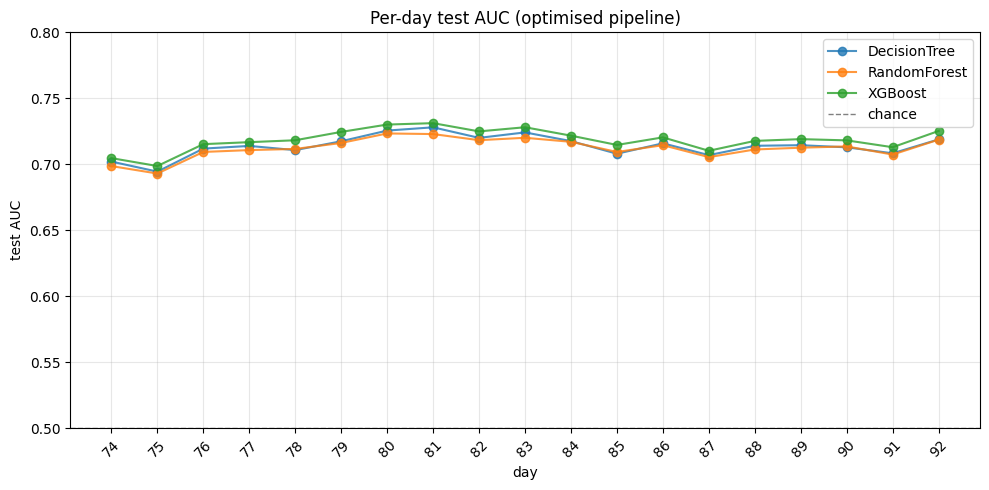

In [33]:
# Plot: Per-Day AUC
# =================================================================================

fig, ax = plt.subplots(figsize=(10, 5))
for name, grp in per_day.groupby('model'):
    grp = grp.sort_values('day')
    ax.plot(grp['day'], grp['auc'], marker='o', label=name, alpha=0.8)
ax.axhline(0.5, color='grey', linestyle='--', linewidth=1, label='chance')
ax.set_ylim(0.5, 0.8)            
ax.set_xticks(range(int(per_day['day'].min()), int(per_day['day'].max()) + 1))
ax.set_xticklabels(range(int(per_day['day'].min()), int(per_day['day'].max()) + 1), rotation=45)
ax.set_xlabel('day')
ax.set_ylabel('test AUC')
ax.set_title('Per-day test AUC (optimised pipeline)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../data/processed/modeling/classification/per_day_test_auc_optimised.png', dpi=120)
plt.show()

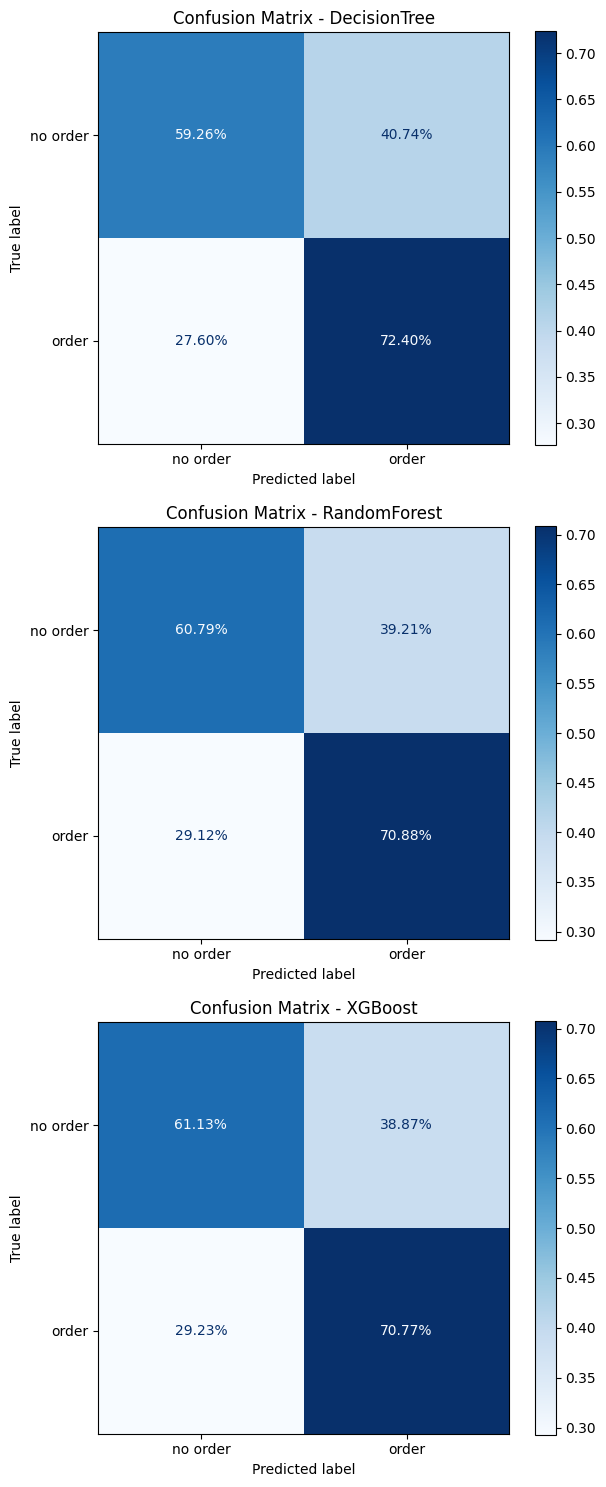

In [34]:
# Plot: Confusion Matrices
# ================================================================================

fig, axes = plt.subplots(3, 1, figsize=(6, 15))

for ax, (name, search) in zip(axes, searches.items()):
    # Use the same threshold as in evaluation (F1-optimal from cal set)
    thr, _ = tune_threshold(y_cal, cal_probs[name])
    y_pred = (test_probs[name] >= thr).astype(int)

    cm = confusion_matrix(y_test, y_pred, normalize='true')
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['no order', 'order'])
    disp.plot(ax=ax, cmap='Blues', colorbar=True, values_format='.2%')
    ax.set_title(f'Confusion Matrix - {name}')

plt.tight_layout()

# Save
out_path = Path('../data/processed/modeling/classification/confusion_matrices.png')
out_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out_path, dpi=120)
plt.show()



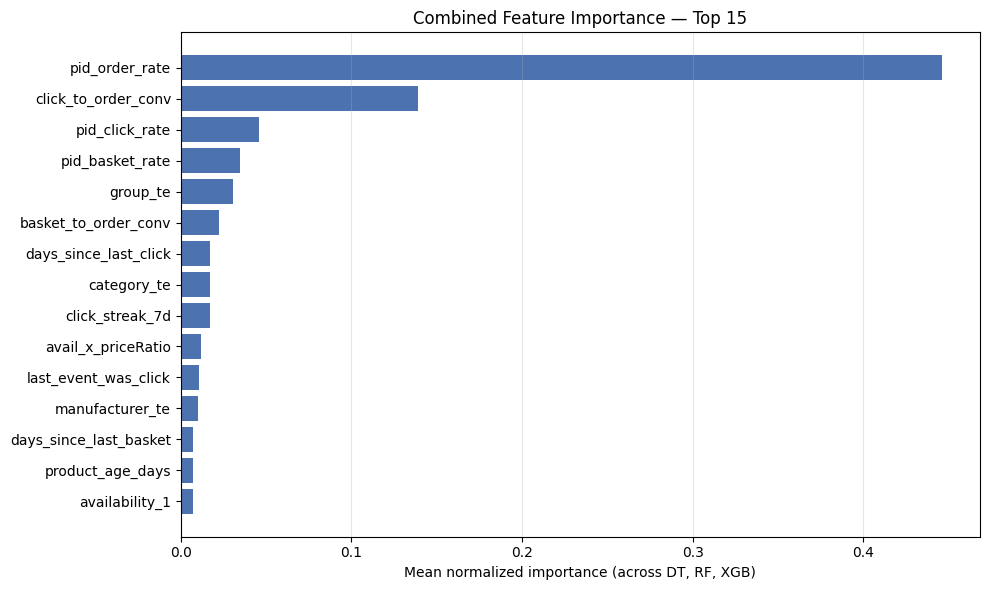

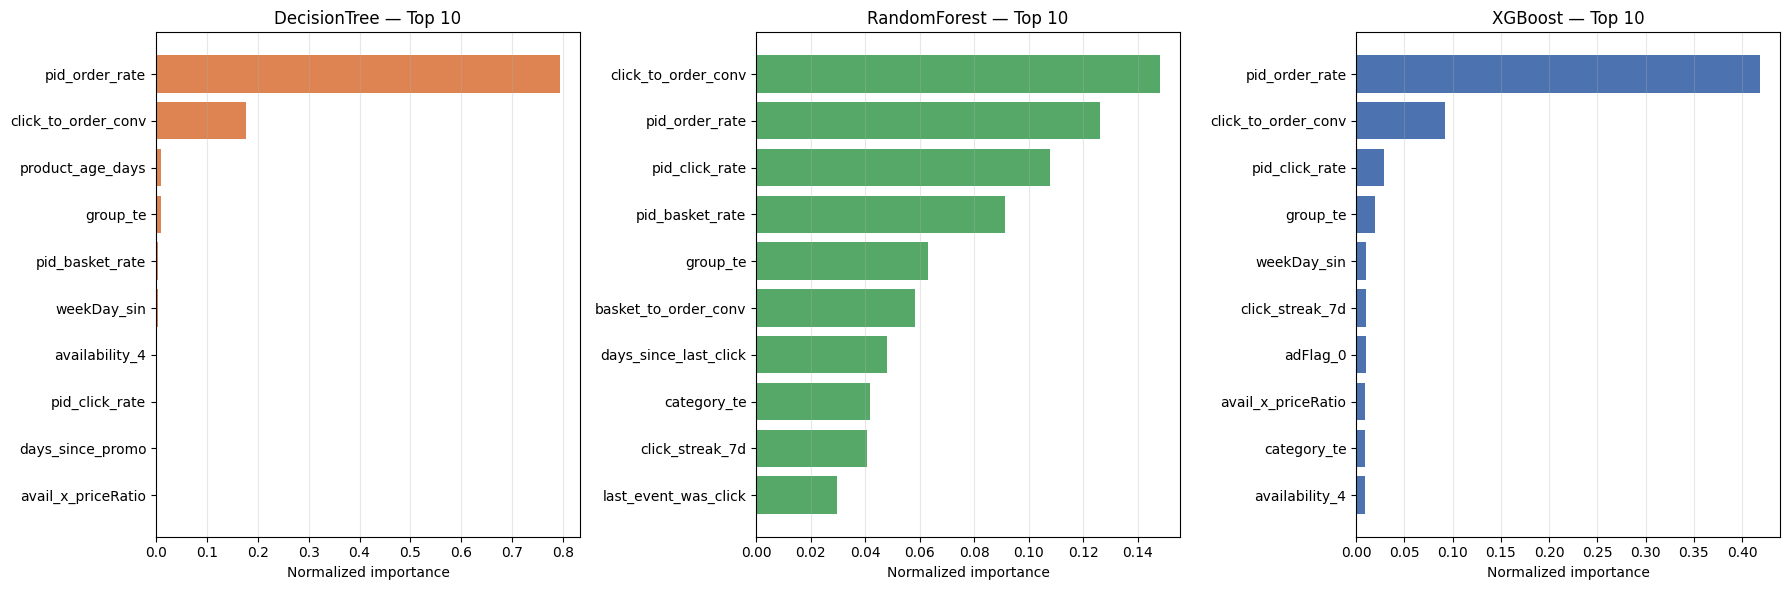


Top 10 Combined Features:
                           DT      RF     XGB  Combined
pid_order_rate         0.7936  0.1262  0.4183    0.4460
click_to_order_conv    0.1767  0.1481  0.0917    0.1389
pid_click_rate         0.0009  0.1079  0.0291    0.0460
pid_basket_rate        0.0037  0.0915  0.0085    0.0346
group_te               0.0101  0.0630  0.0190    0.0307
basket_to_order_conv   0.0000  0.0583  0.0080    0.0221
days_since_last_click  0.0000  0.0480  0.0039    0.0173
category_te            0.0000  0.0419  0.0089    0.0170
click_streak_7d        0.0000  0.0408  0.0098    0.0168
avail_x_priceRatio     0.0003  0.0253  0.0091    0.0116


In [35]:
# Plot: Feature Importance (combined + individual)
# =================================================================================

# Collect normalized importances per model
importances = {}
for name, search in searches.items():
    if hasattr(search.best_estimator_, 'feature_importances_'):
        imp = get_feature_importance(search.best_estimator_, name,
                                      active_num, active_cat, encoder)
        # Normalize so they're comparable across models
        importances[name] = imp / imp.sum()

# Combined: average normalized importance across models
combined = pd.concat(importances.values(), axis=1).fillna(0).mean(axis=1)
combined = combined.sort_values(ascending=False)

# ---- Plot 1: Combined top 15 ----
fig, ax = plt.subplots(figsize=(10, 6))
top_combined = combined.head(15).sort_values()  # ascending for horizontal bar
ax.barh(top_combined.index, top_combined.values, color='#4C72B0')
ax.set_xlabel('Mean normalized importance (across DT, RF, XGB)')
ax.set_title('Combined Feature Importance — Top 15')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()

out_path = Path('../data/processed/modeling/feature_importance_combined.png')
out_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out_path, dpi=120)
plt.show()

# ---- Plot 2: Individual models (3 side-by-side) ----
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = {'DecisionTree': '#DD8452', 'RandomForest': '#55A868', 'XGBoost': '#4C72B0'}

for ax, (name, imp) in zip(axes, importances.items()):
    top10 = imp.head(10).sort_values()
    ax.barh(top10.index, top10.values, color=colors[name])
    ax.set_xlabel('Normalized importance')
    ax.set_title(f'{name} — Top 10')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
out_path = Path('../data/processed/modeling/classification/feature_importance_individual.png')
plt.savefig(out_path, dpi=120)
plt.show()

# Save as CSV for the report
combined_df = pd.concat([importances['DecisionTree'].rename('DT'),
                          importances['RandomForest'].rename('RF'),
                          importances['XGBoost'].rename('XGB'),
                          combined.rename('Combined')], axis=1).fillna(0)
combined_df = combined_df.sort_values('Combined', ascending=False)
combined_df.head(20).to_csv('../data/processed/modeling/classification/feature_importance.csv')
print("\nTop 10 Combined Features:")
print(combined_df.head(10).round(4).to_string())

In [36]:
# Save outputs
# =================================================================================

out_dir = Path('../data/processed/modeling/classification')
out_dir.mkdir(parents=True, exist_ok=True)

per_day.to_csv(out_dir / 'per_day_test_metrics.csv', index=False)
band.to_csv(out_dir / 'test_threshold_band.csv', index=False)
pd.DataFrame(test_results).to_csv(out_dir / 'final_test_results.csv', index=False)



In [37]:
# Final Summary
# =================================================================================

# Print final summary
print("Pipeline completed successfully.")
best_model_row = max(test_results, key=lambda r: r['test_auc'])
print(f"Best model: {best_model_row['model']} | Test AUC = {best_model_row['test_auc']:.4f} | Test F1 = {best_model_row['test_f1']:.4f}")

Pipeline completed successfully.
Best model: XGBoost | Test AUC = 0.7188 | Test F1 = 0.4869


In [38]:
# Check test set distribution
print(f"X_test rows: {len(X_test)}, y_test rows: {len(y_test)}")
print(f"X_test pos rate: {df.loc[X_test['_orig_idx'].values if '_orig_idx' in X_test.columns else X_test.index, 'order'].mean():.3f}")
print(f"y_test pos rate: {y_test.mean():.3f}")

X_test rows: 630764, y_test rows: 630764
X_test pos rate: 0.347
y_test pos rate: 0.245


In [39]:
print(f"y_test pos rate: {y_test.mean():.3f}")
print(f"Train pos rate:  {y_dev.mean():.3f}")

y_test pos rate: 0.245
Train pos rate:  0.220
